# **DATASET: diabetes_012_health_indicators_BRFSS2015**

In [ ]:
# =======================================================================
# 1. SETUP & IMPORT Library
# =======================================================================
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

BASE_DIR = "/content/drive/MyDrive/ML2026"
OUTPUT_DIR = os.path.join(BASE_DIR, "outputDBSCAN_012")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
N_SAMPLE = 10000   # ukuran sampel untuk DBSCAN manual
np.random.seed(RANDOM_STATE)

print("[INFO] Library berhasil diinstall.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE} | N_SAMPLE: {N_SAMPLE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Library berhasil diinstall.
[INFO] Folder output: '/content/drive/MyDrive/ML2026/outputDBSCAN_012' | Random state: 42 | N_SAMPLE: 10000


In [ ]:
# =======================================================================
# 2. LOAD DATA HASIL PREPROCESSING, STANDARDISASI, & SAMPLING
# =======================================================================
df_pre = pd.read_csv(os.path.join(BASE_DIR, "dataset_preprocessed_012.csv"))
print(f"[DATA] Data hasil preprocessing: {df_pre.shape[0]} baris x {df_pre.shape[1]} kolom")

# Pisahkan fitur dan label (label HANYA untuk pembanding, tidak dipakai klastering)
y_label = df_pre['Diabetes_binary'].copy()
df_features = df_pre.drop(columns=['Diabetes_binary']).astype(float)
print(f"[DATA] Jumlah fitur: {df_features.shape[1]} -> {list(df_features.columns)}")
print(f"[DATA] Sebaran kelas: {y_label.value_counts().sort_index().to_dict()}")

# Standardisasi (wajib untuk jarak Euclidean)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)
print(f"[DATA] Bentuk data siap klaster: {X_scaled.shape}")
print(f"[DATA] Cek mean 0 dan std 1: {X_scaled.mean():.4f} / {X_scaled.std():.4f}")

# ---------- SAMPLING (agar DBSCAN manual muat di memori Colab) ----------
rng = np.random.RandomState(RANDOM_STATE)
idx_sample = np.sort(rng.choice(len(X_scaled), size=N_SAMPLE, replace=False))

X_sample = X_scaled[idx_sample]
y_sample = y_label.iloc[idx_sample].reset_index(drop=True)
df_sample_features = df_features.iloc[idx_sample].reset_index(drop=True)

print(f"[SAMPEL] Data klastering: {X_sample.shape[0]} baris x {X_sample.shape[1]} kolom")
print(f"[SAMPEL] Sebaran label (pembanding): {y_sample.value_counts().sort_index().to_dict()}")
df_sample_features.head()

[DATA] Data hasil preprocessing: 208858 baris x 21 kolom
[DATA] Jumlah fitur: 20 -> ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']
[DATA] Sebaran kelas: {0: 174256, 1: 34602}
[DATA] Bentuk data siap klaster: (208858, 20)
[DATA] Cek mean 0 dan std 1: -0.0000 / 1.0000
[SAMPEL] Data klastering: 10000 baris x 20 kolom
[SAMPEL] Sebaran label (pembanding): {0: 8316, 1: 1684}


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education
0,0.0,0.0,1.0,26.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,15.0,0.0,0.0,7.0,5.0
1,1.0,1.0,1.0,27.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,4.0,2.0,0.0,1.0,7.0,6.0
2,1.0,1.0,1.0,30.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,9.0,6.0
3,1.0,1.0,1.0,32.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,4.0
4,0.0,0.0,0.0,24.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,10.0,0.0,0.0,0.0,6.0,3.0


[PARAM] MinPts = 40
[K-DIST] Saran eps dari siku kurva: 4.6127
[K-DIST] Persentil ke-50: 2.7690
[K-DIST] Persentil ke-75: 3.6467
[K-DIST] Persentil ke-90: 4.4344
[K-DIST] Persentil ke-95: 4.9454
[K-DIST] Persentil ke-99: 6.0649
[SIMPAN] Grafik k-distance disimpan ke: '/content/drive/MyDrive/ML2026/outputDBSCAN_012/kdistance_euclidean_012.png'


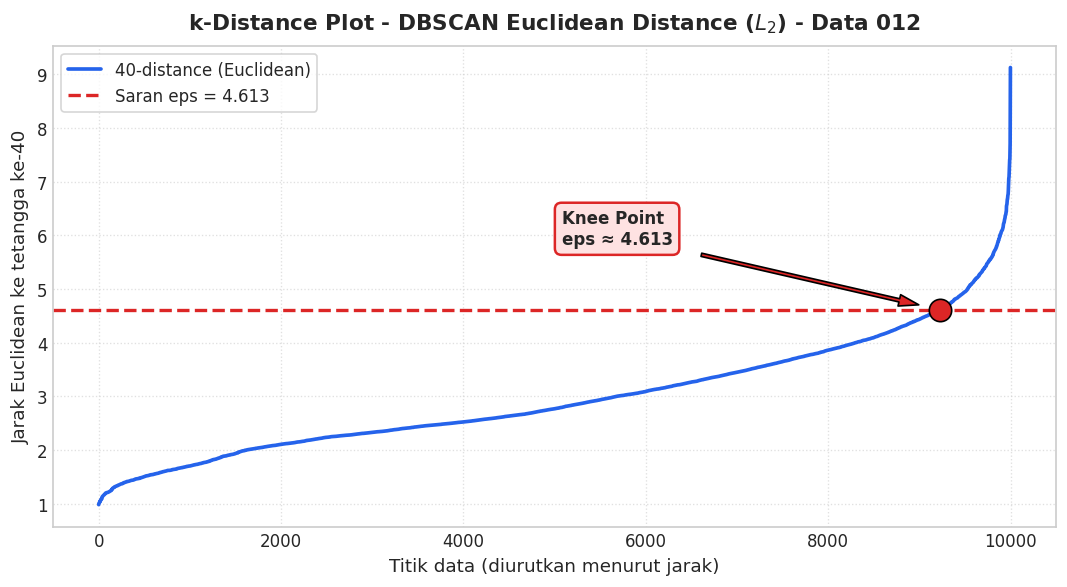

In [ ]:
# =======================================================================
# 3. k-DISTANCE PLOT & PENENTUAN EPS (pengganti Elbow Method)
# =======================================================================
MIN_PTS = 2 * X_sample.shape[1]     # heuristik: 2 x dimensi = 40
print(f"[PARAM] MinPts = {MIN_PTS}")

# Jarak Euclidean ke tetangga ke-MinPts (termasuk dirinya sendiri)
nbrs = NearestNeighbors(n_neighbors=MIN_PTS, metric='euclidean', algorithm='brute')
nbrs.fit(X_sample)
distances, _ = nbrs.kneighbors(X_sample)
k_dist = np.sort(distances[:, -1])          # urut naik

# Deteksi siku: jarak tegak lurus terjauh dari garis penghubung titik awal-akhir
# (kedua sumbu dinormalisasi 0-1 supaya skala indeks tidak mendominasi)
def find_knee_point(y_vals):
    x = np.arange(len(y_vals), dtype=float)
    xn = (x - x.min()) / (x.max() - x.min())
    yn = (y_vals - y_vals.min()) / (y_vals.max() - y_vals.min())
    p1 = np.array([xn[0], yn[0]])
    p2 = np.array([xn[-1], yn[-1]])
    line_vec = p2 - p1
    line_unit = line_vec / np.linalg.norm(line_vec)
    pts = np.column_stack([xn, yn]) - p1
    proj = np.outer(pts @ line_unit, line_unit)
    dists = np.linalg.norm(pts - proj, axis=1)
    return int(np.argmax(dists))

knee_idx = find_knee_point(k_dist)
eps_suggest = float(k_dist[knee_idx])
print(f"[K-DIST] Saran eps dari siku kurva: {eps_suggest:.4f}")

# Kuantil sebagai pembanding
for q in [50, 75, 90, 95, 99]:
    print(f"[K-DIST] Persentil ke-{q}: {np.percentile(k_dist, q):.4f}")

# Plot
plt.figure(figsize=(9, 5))
plt.plot(np.arange(len(k_dist)), k_dist, linewidth=2.2, color='#2563EB', label=f'{MIN_PTS}-distance (Euclidean)')
plt.axhline(y=eps_suggest, color='#DC2626', linestyle='--', linewidth=2, label=f'Saran eps = {eps_suggest:.3f}')
plt.scatter([knee_idx], [eps_suggest], color='#DC2626', s=180, zorder=5, edgecolor='black')

plt.title('k-Distance Plot - DBSCAN Euclidean Distance ($L_2$) - Data 012', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Titik data (diurutkan menurut jarak)', fontsize=11)
plt.ylabel(f'Jarak Euclidean ke tetangga ke-{MIN_PTS}', fontsize=11)
plt.annotate(
    f'Knee Point\neps ≈ {eps_suggest:.3f}',
    xy=(knee_idx, eps_suggest),
    xytext=(knee_idx * 0.55, eps_suggest + (k_dist.max() - k_dist.min()) * 0.15),
    arrowprops=dict(facecolor='#DC2626', shrink=0.08, width=2, headwidth=7),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FEE2E2", edgecolor="#DC2626", lw=1.5),
    fontweight='bold', fontsize=10
)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

kdist_path = os.path.join(OUTPUT_DIR, "kdistance_euclidean_012.png")
plt.savefig(kdist_path, dpi=300)
print(f"[SIMPAN] Grafik k-distance disimpan ke: '{kdist_path}'")
plt.show()

In [ ]:
# =======================================================================
# 4. KELAS DBSCAN EUCLIDEAN
# =======================================================================
from collections import deque
from sklearn.cluster import DBSCAN                 # HANYA untuk uji validasi, bukan hasil utama
from sklearn.metrics import adjusted_rand_score

class DBSCANEuclidean:
    def __init__(self, eps=0.5, min_pts=5, chunk_size=1000):
        self.eps = eps
        self.min_pts = min_pts
        self.chunk_size = chunk_size
        self.labels_ = None
        self.core_sample_mask_ = None
        self.n_clusters_ = 0
        self.n_noise_ = 0
        self.execution_time_ = 0.0

    def _compute_neighborhoods(self, X):
        # N_eps(p) = { q | ||p - q||_2 <= eps }  (termasuk titik p sendiri)
        neighborhoods = []
        for start in range(0, len(X), self.chunk_size):
            dists = pairwise_distances(X[start:start + self.chunk_size], X, metric='euclidean')
            for row in dists:
                neighborhoods.append(np.where(row <= self.eps)[0])
        return neighborhoods

    def fit(self, X):
        start_time = time.perf_counter()
        n_samples = X.shape[0]

        # 1) Hitung ketetanggaan-eps semua titik
        neighborhoods = self._compute_neighborhoods(X)

        # 2) Core point: |N_eps(p)| >= MinPts
        is_core = np.array([len(nb) >= self.min_pts for nb in neighborhoods])

        # 3) Ekspansi klaster dari core point (-1 = noise)
        labels = np.full(n_samples, -1, dtype=int)
        visited = np.zeros(n_samples, dtype=bool)
        cluster_id = 0

        for p in range(n_samples):
            if visited[p] or not is_core[p]:
                continue
            # core point baru -> mulai klaster baru
            visited[p] = True
            labels[p] = cluster_id
            seeds = deque([p])

            while seeds:
                q = seeds.popleft()                      # q adalah core point
                nb = neighborhoods[q]
                # tetangga yang belum berlabel (border/core) masuk klaster ini
                labels[nb[labels[nb] == -1]] = cluster_id
                # core point tetangga yang belum dikunjungi ikut diekspansi
                new_core = nb[(~visited[nb]) & is_core[nb]]
                visited[new_core] = True
                seeds.extend(new_core.tolist())

            cluster_id += 1

        self.labels_ = labels
        self.core_sample_mask_ = is_core
        self.n_clusters_ = cluster_id
        self.n_noise_ = int(np.sum(labels == -1))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas DBSCANEuclidean berhasil diinisialisasi.")

[INFO] Kelas DBSCANEuclidean berhasil diinisialisasi.


In [ ]:
# =======================================================================
# 4b. UJI VALIDASI: bandingkan dengan DBSCAN sklearn (eps & MinPts sama)
# =======================================================================
EPS_TEST = 3.0

mine = DBSCANEuclidean(eps=EPS_TEST, min_pts=MIN_PTS).fit(X_sample)
ref = DBSCAN(eps=EPS_TEST, min_samples=MIN_PTS, metric='euclidean').fit(X_sample)

ref_core_mask = np.zeros(len(X_sample), dtype=bool)
ref_core_mask[ref.core_sample_indices_] = True

print(f"[VALIDASI] eps = {EPS_TEST} | MinPts = {MIN_PTS}")
print(f"[VALIDASI] Manual : {mine.n_clusters_} klaster, {mine.n_noise_} noise, {mine.execution_time_:.2f} detik")
print(f"[VALIDASI] sklearn: {len(set(ref.labels_)) - (1 if -1 in ref.labels_ else 0)} klaster, {int(np.sum(ref.labels_ == -1))} noise")
print(f"[VALIDASI] Core point identik : {np.array_equal(mine.core_sample_mask_, ref_core_mask)}")
print(f"[VALIDASI] Noise identik      : {np.array_equal(mine.labels_ == -1, ref.labels_ == -1)}")
print(f"[VALIDASI] Adjusted Rand Index: {adjusted_rand_score(ref.labels_, mine.labels_):.4f}")

[VALIDASI] eps = 3.0 | MinPts = 40
[VALIDASI] Manual : 6 klaster, 2540 noise, 4.04 detik
[VALIDASI] sklearn: 6 klaster, 2540 noise
[VALIDASI] Core point identik : True
[VALIDASI] Noise identik      : True
[VALIDASI] Adjusted Rand Index: 1.0000


In [ ]:
# =======================================================================
# 5. UJI BEBERAPA NILAI EPS
# =======================================================================
eps_candidates = [2.5, 3.0, 3.5, 4.0, 4.5, round(eps_suggest, 3), 5.0]
rows = []

for eps in eps_candidates:
    m = DBSCANEuclidean(eps=eps, min_pts=MIN_PTS).fit(X_sample)
    lab = m.labels_
    mask = lab != -1

    if m.n_clusters_ > 0:
        sizes = np.bincount(lab[mask])
        largest_pct = sizes.max() / len(lab) * 100
    else:
        largest_pct = 0.0

    # Silhouette hanya pada titik non-noise dan jika klaster >= 2
    if m.n_clusters_ >= 2 and mask.sum() > m.n_clusters_:
        sil = silhouette_score(X_sample[mask], lab[mask], metric='euclidean')
    else:
        sil = np.nan

    rows.append({
        'eps': eps,
        'Jumlah Klaster': m.n_clusters_,
        'Noise (n)': m.n_noise_,
        'Noise (%)': round(m.n_noise_ / len(lab) * 100, 2),
        'Klaster Terbesar (%)': round(largest_pct, 2),
        'Core Point (n)': int(m.core_sample_mask_.sum()),
        'Silhouette (non-noise)': round(sil, 4) if not np.isnan(sil) else np.nan,
        'Waktu (s)': round(m.execution_time_, 2)
    })
    print(f"[SWEEP] eps={eps} selesai -> {m.n_clusters_} klaster, noise {m.n_noise_/len(lab)*100:.2f}%")

sweep_df = pd.DataFrame(rows)
print("\n" + "=" * 100)
print("TABEL UJI EPS - DBSCAN EUCLIDEAN (DATA 012)")
print("=" * 100)
print(sweep_df.to_string(index=False))
print("=" * 100)

sweep_path = os.path.join(OUTPUT_DIR, "eps_sweep_euclidean_012.csv")
sweep_df.to_csv(sweep_path, index=False)
print(f"[SIMPAN] Tabel uji eps disimpan ke: '{sweep_path}'")

[SWEEP] eps=2.5 selesai -> 7 klaster, noise 41.50%
[SWEEP] eps=3.0 selesai -> 6 klaster, noise 25.40%
[SWEEP] eps=3.5 selesai -> 5 klaster, noise 13.73%
[SWEEP] eps=4.0 selesai -> 5 klaster, noise 6.54%
[SWEEP] eps=4.5 selesai -> 3 klaster, noise 2.64%
[SWEEP] eps=4.613 selesai -> 3 klaster, noise 2.17%
[SWEEP] eps=5.0 selesai -> 1 klaster, noise 0.87%

TABEL UJI EPS - DBSCAN EUCLIDEAN (DATA 012)
  eps  Jumlah Klaster  Noise (n)  Noise (%)  Klaster Terbesar (%)  Core Point (n)  Silhouette (non-noise)  Waktu (s)
2.500               7       4150      41.50                 50.35            3876                  0.1279       2.91
3.000               6       2540      25.40                 60.73            5677                  0.1686       2.23
3.500               5       1373      13.73                 75.19            7136                  0.2066       2.81
4.000               5        654       6.54                 78.93            8303                  0.2005       1.96
4.500          

[SWEEP-HALUS] eps=2.3 selesai
[SWEEP-HALUS] eps=2.4 selesai
[SWEEP-HALUS] eps=2.5 selesai
[SWEEP-HALUS] eps=2.6 selesai
[SWEEP-HALUS] eps=2.7 selesai
[SWEEP-HALUS] eps=2.8 selesai
[SWEEP-HALUS] eps=2.9 selesai
[SWEEP-HALUS] eps=3.0 selesai
[SWEEP-HALUS] eps=3.1 selesai
[SWEEP-HALUS] eps=3.2 selesai
[SWEEP-HALUS] eps=3.3 selesai
[SWEEP-HALUS] eps=3.4 selesai

TABEL UJI EPS HALUS - DBSCAN EUCLIDEAN (DATA 012)
 eps  Jumlah Klaster  Klaster >=1% data  Noise (%)  Klaster Terbesar (%) Ukuran 5 Klaster Terbesar
 2.3               7                  3      55.15                 36.97    3697, 486, 130, 51, 49
 2.4               7                  4      48.63                 39.52   3952, 693, 193, 128, 66
 2.5               7                  5      41.50                 50.35  5035, 241, 227, 113, 107
 2.6               6                  5      36.50                 54.25  5425, 322, 267, 143, 131
 2.7               6                  5      33.00                 56.40  5640, 349, 313, 165,

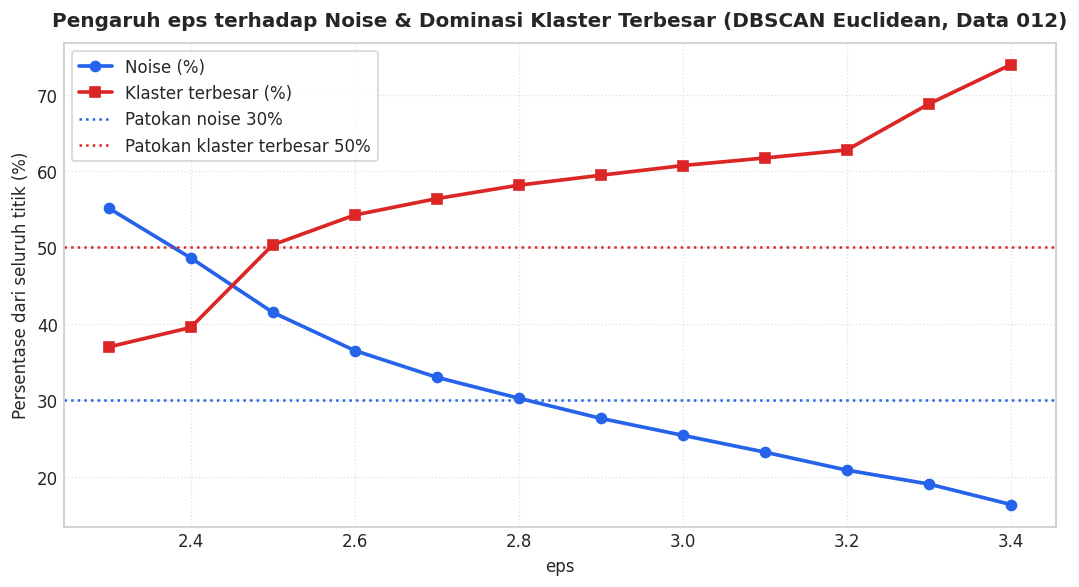

In [ ]:
# =======================================================================
# 5b. UJI EPS HALUS (2.3 - 3.4)
# =======================================================================
eps_fine = [2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4]
rows = []

for eps in eps_fine:
    m = DBSCANEuclidean(eps=eps, min_pts=MIN_PTS).fit(X_sample)
    lab = m.labels_
    mask = lab != -1
    n = len(lab)

    if m.n_clusters_ > 0:
        sizes = np.sort(np.bincount(lab[mask]))[::-1]
    else:
        sizes = np.array([0])

    rows.append({
        'eps': eps,
        'Jumlah Klaster': m.n_clusters_,
        'Klaster >=1% data': int(np.sum(sizes >= 0.01 * n)),
        'Noise (%)': round(m.n_noise_ / n * 100, 2),
        'Klaster Terbesar (%)': round(sizes[0] / n * 100, 2),
        'Ukuran 5 Klaster Terbesar': ', '.join(map(str, sizes[:5]))
    })
    print(f"[SWEEP-HALUS] eps={eps} selesai")

fine_df = pd.DataFrame(rows)
print("\n" + "=" * 110)
print("TABEL UJI EPS HALUS - DBSCAN EUCLIDEAN (DATA 012)")
print("=" * 110)
print(fine_df.to_string(index=False))
print("=" * 110)

fine_path = os.path.join(OUTPUT_DIR, "eps_sweep_halus_euclidean_012.csv")
fine_df.to_csv(fine_path, index=False)
print(f"[SIMPAN] Tabel disimpan ke: '{fine_path}'")

# Grafik: noise (%) dan klaster terbesar (%) terhadap eps
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(fine_df['eps'], fine_df['Noise (%)'], marker='o', linewidth=2.2, color='#2563EB', label='Noise (%)')
ax.plot(fine_df['eps'], fine_df['Klaster Terbesar (%)'], marker='s', linewidth=2.2, color='#DC2626', label='Klaster terbesar (%)')
ax.axhline(30, color='#2563EB', linestyle=':', linewidth=1.5, label='Patokan noise 30%')
ax.axhline(50, color='#DC2626', linestyle=':', linewidth=1.5, label='Patokan klaster terbesar 50%')
ax.set_title('Pengaruh eps terhadap Noise & Dominasi Klaster Terbesar (DBSCAN Euclidean, Data 012)', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('eps')
ax.set_ylabel('Persentase dari seluruh titik (%)')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(frameon=True, facecolor='white')
plt.tight_layout()

fine_png = os.path.join(OUTPUT_DIR, "eps_halus_euclidean_012.png")
plt.savefig(fine_png, dpi=300)
print(f"[SIMPAN] Grafik disimpan ke: '{fine_png}'")
plt.show()

In [ ]:
# =======================================================================
# 6. EKSEKUSI AKHIR, METRIK EVALUASI, PROFIL KLASTER, & EKSPOR EXCEL
# =======================================================================
EPS_FINAL = 2.8      # ubah di sini jika memilih eps lain

model_dbscan = DBSCANEuclidean(eps=EPS_FINAL, min_pts=MIN_PTS).fit(X_sample)
labels = model_dbscan.labels_
mask = labels != -1
n_total = len(labels)

# Metrik evaluasi dihitung pada titik NON-NOISE (noise bukan klaster)
if model_dbscan.n_clusters_ >= 2:
    sil_score = float(silhouette_score(X_sample[mask], labels[mask], metric='euclidean'))
    db_score = float(davies_bouldin_score(X_sample[mask], labels[mask]))
    ch_score = float(calinski_harabasz_score(X_sample[mask], labels[mask]))
else:
    sil_score = db_score = ch_score = np.nan

sizes = np.bincount(labels[mask]) if model_dbscan.n_clusters_ > 0 else np.array([0])

eval_df = pd.DataFrame([{
    'Distance Metric': 'Euclidean Distance (L2)',
    'eps': EPS_FINAL,
    'MinPts': MIN_PTS,
    'Jumlah Data Dipakai': n_total,
    'Jumlah Klaster': model_dbscan.n_clusters_,
    'Klaster >=1% data': int(np.sum(sizes >= 0.01 * n_total)),
    'Noise (n)': model_dbscan.n_noise_,
    'Noise (%)': round(model_dbscan.n_noise_ / n_total * 100, 2),
    'Core Point (n)': int(model_dbscan.core_sample_mask_.sum()),
    'Silhouette Score (non-noise) (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (non-noise) (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (non-noise) (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_dbscan.execution_time_, 5)
}])

print("\n" + "=" * 80)
print("TABEL EVALUASI DBSCAN EUCLIDEAN (DATA 012)")
print("=" * 80)
print(eval_df.T.to_string(header=False))
print("=" * 80)

# ---------- Profil klaster: rata-rata fitur asli per klaster ----------
df_result = df_sample_features.copy()
df_result['Cluster_DBSCAN'] = labels
df_result['Diabetes_binary'] = y_sample.values

fitur = list(df_sample_features.columns)
profil = df_result.groupby('Cluster_DBSCAN')[fitur].mean().round(2)
profil.insert(0, 'Jumlah Titik', df_result.groupby('Cluster_DBSCAN').size())
profil.insert(1, 'Persen Data (%)', (profil['Jumlah Titik'] / n_total * 100).round(2))

print("\nPROFIL KLASTER (label -1 = noise):")
print(profil.T.to_string())

# ---------- Perbandingan klaster vs label diabetes (pembanding) ----------
label_vs = pd.crosstab(df_result['Cluster_DBSCAN'], df_result['Diabetes_binary'])
label_vs.columns = ['Tidak Diabetes (0)', 'Diabetes (1)']
label_vs['Total'] = label_vs.sum(axis=1)
label_vs['Diabetes (%)'] = (label_vs['Diabetes (1)'] / label_vs['Total'] * 100).round(2)

print(f"\nKLASTER vs LABEL (proporsi diabetes seluruh sampel = {y_sample.mean() * 100:.2f}%):")
print(label_vs.to_string())

# ---------- Simpan ke Excel (4 sheet) ----------
excel_path = os.path.join(OUTPUT_DIR, "evaluasi_dbscan_euclidean_012.xlsx")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    profil.to_excel(writer, sheet_name='Profil_Klaster')
    label_vs.to_excel(writer, sheet_name='Klaster_vs_Label')
    df_result.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"\n[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '{excel_path}'")


TABEL EVALUASI DBSCAN EUCLIDEAN (DATA 012)
Distance Metric                          Euclidean Distance (L2)
eps                                                          2.8
MinPts                                                        40
Jumlah Data Dipakai                                        10000
Jumlah Klaster                                                 6
Klaster >=1% data                                              5
Noise (n)                                                   3026
Noise (%)                                                  30.26
Core Point (n)                                              5093
Silhouette Score (non-noise) (↑)                          0.1652
Davies–Bouldin Index (non-noise) (↓)                      1.4672
Calinski–Harabasz Index (non-noise) (↑)                   360.24
Execution Time (s) (↓)                                   6.04727

PROFIL KLASTER (label -1 = noise):
Cluster_DBSCAN             -1        0       1       2       3       4     

[SIMPAN] Grafik pemetaan klaster disimpan ke: '/content/drive/MyDrive/ML2026/outputDBSCAN_012/cluster_dbscan_euclidean_012.png'


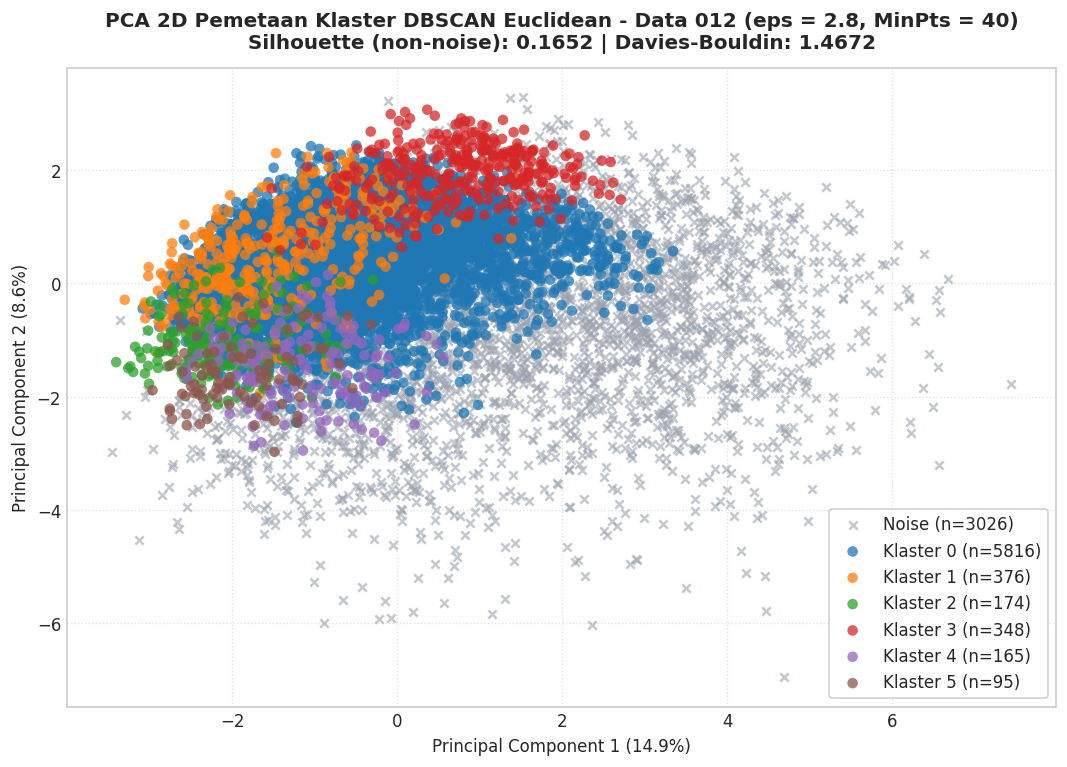

In [ ]:
# =======================================================================
# 7. VISUALISASI PCA 2D PEMETAAN KLASTER
# =======================================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(9, 6.5))
n_cl = model_dbscan.n_clusters_
palette = sns.color_palette("tab10", max(n_cl, 1))

# Noise digambar dulu (di belakang)
m_noise = labels == -1
plt.scatter(X_pca[m_noise, 0], X_pca[m_noise, 1],
            c='#9CA3AF', marker='x', s=25, alpha=0.6,
            label=f'Noise (n={m_noise.sum()})')

for k in range(n_cl):
    mk = labels == k
    plt.scatter(X_pca[mk, 0], X_pca[mk, 1],
                color=palette[k], label=f'Klaster {k} (n={mk.sum()})',
                alpha=0.75, s=40, edgecolors='none')

plt.title(f'PCA 2D Pemetaan Klaster DBSCAN Euclidean - Data 012 (eps = {EPS_FINAL}, MinPts = {MIN_PTS})\n'
          f'Silhouette (non-noise): {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=12, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_dbscan_euclidean_012.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

In [ ]:
# =======================================================================
# 8. BUKTI PENDUKUNG LAPORAN
# =======================================================================
# a) Kesesuaian klaster (non-noise) dengan label diabetes
ari_label = adjusted_rand_score(y_sample.values[mask], labels[mask])
diab_total = int((y_sample == 1).sum())
diab_noise = int(((labels == -1) & (y_sample.values == 1)).sum())
print(f"[BUKTI] ARI klaster vs label (non-noise): {ari_label:.4f}")
print(f"[BUKTI] Diabetes di noise: {diab_noise} dari {diab_total} ({diab_noise / diab_total * 100:.2f}%)")

# b) Tabel silang flag biner langka penentu klaster
flag_cols = ['Stroke', 'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'CholCheck', 'NoDocbcCost', 'AnyHealthcare']
crosstabs = {}
for f in flag_cols:
    crosstabs[f] = pd.crosstab(df_result['Cluster_DBSCAN'], df_result[f])
    print(f"\n[BUKTI] Klaster vs {f}:")
    print(crosstabs[f].to_string())

# c) Jarak untuk SATU perbedaan nilai pada tiap fitur biner (setelah standardisasi)
#    = 1 / sigma, dengan sigma dari scaler yang dipasang pada seluruh 208.858 baris
gap_rows = []
for col, sigma in zip(df_features.columns, scaler.scale_):
    if df_features[col].nunique() == 2:
        gap_rows.append({
            'Fitur': col,
            'Proporsi nilai 1': round(df_features[col].mean(), 3),
            'Sigma': round(sigma, 4),
            'Jarak 1 perbedaan': round(1 / sigma, 3),
            f'Melebihi eps ({EPS_FINAL})': (1 / sigma) > EPS_FINAL
        })
gap_df = pd.DataFrame(gap_rows).sort_values('Jarak 1 perbedaan', ascending=False)
print("\n[BUKTI] Jarak Euclidean untuk satu perbedaan pada fitur biner:")
print(gap_df.to_string(index=False))

# Simpan ke Excel
bukti_path = os.path.join(OUTPUT_DIR, "bukti_pendukung_dbscan_012.xlsx")
with pd.ExcelWriter(bukti_path, engine='openpyxl') as writer:
    gap_df.to_excel(writer, sheet_name='Jarak_Fitur_Biner', index=False)
    for f, ct in crosstabs.items():
        ct.to_excel(writer, sheet_name=f'Klaster_vs_{f}'[:31])
print(f"\n[SIMPAN] Bukti pendukung disimpan ke: '{bukti_path}'")

[BUKTI] ARI klaster vs label (non-noise): -0.0463
[BUKTI] Diabetes di noise: 711 dari 1684 (42.22%)

[BUKTI] Klaster vs Stroke:
Stroke           0.0  1.0
Cluster_DBSCAN           
-1              2559  467
 0              5816    0
 1               376    0
 2               174    0
 3               348    0
 4               165    0
 5                95    0

[BUKTI] Klaster vs HeartDiseaseorAttack:
HeartDiseaseorAttack   0.0  1.0
Cluster_DBSCAN                 
-1                    2279  747
 0                    5816    0
 1                     376    0
 2                     174    0
 3                       0  348
 4                     165    0
 5                      95    0

[BUKTI] Klaster vs HvyAlcoholConsump:
HvyAlcoholConsump   0.0  1.0
Cluster_DBSCAN              
-1                 2719  307
 0                 5816    0
 1                    0  376
 2                  174    0
 3                  348    0
 4                  165    0
 5                   95    0

[BUKTI]